## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually

In [1]:
# NOTE: UNCOMMENT ALL LINES AND RUN CELL IF RUNNING NOTEBOOK ON GOOGLE COLAB
!pip install dotenv
!pip install FinRL
!pip install stable_baselines3
!pip install alpaca_trade_api
!pip install exchange_calendars
!pip install stockstats
!pip install wrds
!pip install websockets
!pip install yfinance
!pip install ta
!pip install sb3_contrib
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip uninstall -y mamba-ssm causal-conv1d
!pip install causal-conv1d==1.4.0
!pip install mamba-ssm==2.2.2

  Using cached websockets-10.4-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached websockets-10.4-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (107 kB)
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 0.8.2 requires websockets>=14.0, but you have websockets 10.4 which is incompatible.
google-genai 1.25.0 requires websockets<15.1.0,>=13.0.0, but you have websockets 10.4 which is incompatible.
yfinance 0.2.65 requires websockets>=13.0, but you have websockets 10.4 which is incompatible.
  Using cached websockets-15.0.1-cp311-cp311-manylinux_2_5_

In [2]:
import os
import sys

# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [3]:
# NOTE: UNCOMMENT ALL LINES AND RUN CELL IF RUNNING NOTEBOOK ON GOOGLE COLAB
import os
import sys
from google.colab import drive

drive.mount('/content/drive')

# NOTE: CHANGE PATH AS NECESSARY
PATH = '/content/drive/MyDrive/ELEN6885 Final Project'
sys.path.append(os.path.join(PATH, 'rl-trading'))

Mounted at /content/drive


In [4]:
from dotenv import load_dotenv
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from gymnasium import spaces
from finrl.meta.preprocessor.preprocessors import data_split
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from mamba_ssm import Mamba

from trading_environment.custom_env import StockTradingEnv
from trading_environment import rewards
from experiments.normalization import MaskedVecNormalize
from experiments.early_stopping import MultiCondEarlyStop
from evaluation.backtest import run_backtest
from evaluation.visualize import plot_trades_on_price_from_backtest
from evaluation import financial_metrics

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.11/dist-packages/mamba_ssm/dis

In [5]:
if not torch.cuda.is_available():
  raise Exception('Please use a GPU compute')

## Load env variables

In [6]:
load_dotenv(r'../.env')

try:
  DATA_DIR = os.getenv('DATA_DIR', os.path.join(PATH, 'data'))
except:
  DATA_DIR = None
print(DATA_DIR)

/content/drive/MyDrive/ELEN6885 Final Project/data


In [7]:
# record experiment start dt
EXP_START_DT = datetime.now().strftime('%Y%m%d_%H%M')
EXP_START_DT

'20251214_0519'

## MAMBA feature extractor

In [8]:
class MambaEncoder(nn.Module):
    def __init__(self, input_dim, d_model, n_layers, dropout):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.dropout = nn.Dropout(dropout)
        self.mamba_blocks = nn.ModuleList([
            Mamba(d_model=d_model, d_state=64, d_conv=4, expand=4)
            for _ in range(n_layers)
        ])
        self.block_norms = nn.ModuleList([
            nn.LayerNorm(d_model) for _ in range(n_layers)
        ])
        self.out_norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = x.float()
        if x.dim() == 2:
            x = x.unsqueeze(0)

        x = self.dropout(self.input_proj(x))

        for ln, block in zip(self.block_norms, self.mamba_blocks):
            h = ln(x)
            h = block(h)
            x = x + self.dropout(h)   # residual

            if not torch.isfinite(x).all():
                raise RuntimeError("Non-finite values after a Mamba block")

        x = self.out_norm(x)
        return x[:, -1, :]

In [9]:
class MambaFeatureExtractor(BaseFeaturesExtractor):
    def __init__(
        self,
        observation_space: spaces.Box,
        d_model: int = 128,
        n_layers: int = 2,
        dropout: float = 0.1,
    ):
        # obs shape: (window_size, features_dim)
        window_size, features_dim = observation_space.shape

        super().__init__(observation_space, features_dim=d_model)

        self.mamba_encoder = MambaEncoder(
            input_dim=features_dim,
            d_model=d_model,
            n_layers=n_layers,
            dropout=dropout,
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        if observations.dim() == 2:
            observations = observations.unsqueeze(0)

        out = self.mamba_encoder(observations)
        if not torch.isfinite(out).all():
            raise RuntimeError("Non-finite output from mamba_encoder")

        return out


## Train-test split and normalization

In [10]:
## ----- CONFIG ----- ##
SPLIT_DATE = '2018-01-01' # format %Y-%m-%d
DATA_FILE_NAME = 'data_with_features.csv'

base_columns = [
    'date',	'tic', 'close',	'high',	'low', 'open', 'volume'
]

stock_features = [
    'atr_30',
    'macd',
    'macd_hist',
    'rsi_30'
]

economy_features = [
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'USEPUINDXD',
    'VIXCLS',
    # 'doy_sin',
    # 'doy_cos',
    # 'dow_sin',
    # 'dow_cos'
]

In [11]:
# load finalized data
data_df = pd.read_csv(os.path.join(DATA_DIR, DATA_FILE_NAME))

data_df = data_df[base_columns + stock_features + economy_features]
stock_names = data_df['tic'].unique()
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df.shape

(67300, 17)

In [12]:
SPLIT_DATE = pd.to_datetime(SPLIT_DATE, format='%Y-%m-%d')

# train-test split
min_date = data_df['date'].min()
max_date = data_df['date'].max()

train_df = data_split(data_df, start=min_date, end=SPLIT_DATE)
trade_df = data_split(data_df, start=SPLIT_DATE + pd.Timedelta(days=1), end=max_date)

print(train_df.shape, trade_df.shape)
print('Any missing values in training:', train_df.isna().any().any())
print('Any missing values in testing:', trade_df.isna().any().any())

(47340, 17) (19950, 17)
Any missing values in training: False
Any missing values in testing: False


## Environment configuration

In [13]:
## ----- CONFIG ----- ##
price = 'close'         # name of price to use for transactions / rewards
hmax = 100              # maximum number of stocks to transact at each step
initial_amount = 5000   # initial amount of cash
buy_cost_pct = 0.005    # % cost of each stock purchase
sell_cost_pct = 0.005   # % cost of each stock sale
num_stock_shares = 0    # number of starting shares
window_size = 7*8       # number of previous time steps to encode
reward_scaling = 1      # reward scaling

In [14]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
state_space = 1 + 2 * stock_dim + len(stock_features) * stock_dim + len(economy_features)

env_kwargs = {
    "price": price,
    "hmax": hmax,
    "initial_amount": initial_amount,
    "buy_cost_pct": [buy_cost_pct] * stock_dim,
    "sell_cost_pct": [sell_cost_pct] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    # "reward_function": rewards.PenalizedTurnover(penalty=0.1),
    "reward_function": rewards.PnLReward(),
    "reward_scaling": 1,
    "num_stock_shares": [num_stock_shares] * stock_dim,
    "price": "close",
    "stock_features": stock_features,
    "economy_features": economy_features,
    "window_size": window_size
}


## Data normalization

In [15]:
## ----- CONFIG ----- ##
PARALLEL_RUNS = 10

In [16]:
# do not normalize prices, since they are used to compute rewards
features_to_normalize = stock_features + economy_features

# get idx of each column
name_to_idx = {name: i for i, name in enumerate(data_df.columns)}

# get idx of features to normalize
col_idx = np.array([name_to_idx[name] for name in features_to_normalize], dtype=int)

In [17]:
def make_train_env():
    env = StockTradingEnv(df=train_df, **env_kwargs)
    env = Monitor(env, filename=f"training_monitor_mamba_{EXP_START_DT}", allow_early_resets=True)
    return env

def make_valid_env():
    env = StockTradingEnv(df=trade_df, **env_kwargs)
    env = Monitor(env, filename=f"trading_monitor_mamba_{EXP_START_DT}", allow_early_resets=True)
    return env

In [18]:
train_vec_env = DummyVecEnv([make_train_env for _ in range(PARALLEL_RUNS)])

obs_shape = train_vec_env.observation_space.shape   # (window_size, feature_dim)

# features_to_normalize = list of indices along the *feature_dim* axis
normalize_mask = np.zeros(obs_shape, dtype=bool)
# broadcast those feature indices over all time steps
normalize_mask[:, col_idx] = True

# Wrap training env with MaskedVecNormalize (this FITS the stats)
train_norm_env = MaskedVecNormalize(
    train_vec_env,
    normalize_mask=normalize_mask.any(axis=0),
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.0,
    training=True
)

## Model training

In [19]:
## ----- CONFIG ----- ##
# Mamba Hyperparameters
d_model = 32  # Dimension of the Mamba model (output dimension of MambaEncoder)
n_layers = 2   # Number of Mamba blocks in the encoder
dropout = 0.1  # Dropout rate for regularization

# Redefine policy kwargs
mamba_policy_kwargs = dict(
    features_extractor_class=MambaFeatureExtractor,
    features_extractor_kwargs=dict(
        d_model=d_model,
        n_layers=n_layers,
        dropout=dropout
    ),
    net_arch=[64, 64]
)

In [20]:
# Initialize the PPO model with MlpPolicy and Mamba arguments
model_mamba = PPO(
    policy="MlpPolicy",
    env=train_norm_env,

    # --- PPO rollout & update ---
    n_steps=64,
    batch_size=32,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,

    # --- Optimization ---
    learning_rate=3e-4,
    max_grad_norm=0.5,
    clip_range=0.15,
    vf_coef=0.5,
    ent_coef=0.10,

    # --- Misc ---
    policy_kwargs=mamba_policy_kwargs,
    verbose=0,
    tensorboard_log="./mamba_ppo_tb/",
)


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [21]:
total_params = sum(p.numel() for p in model_mamba.policy.parameters())
trainable_params = sum(p.numel() for p in model_mamba.policy.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 92,181
Trainable params: 92,181


In [22]:
# early-stopping constraints are non-binding
# used to prevent over-usage of compute
# learning will complete in 1M steps
callback = MultiCondEarlyStop(
    loss_threshold=-1e6,
    loss_window=4,
    max_time_seconds=3600*6,
    verbose=0,
)

model_mamba.learn(
    total_timesteps=1_000_000,
    callback=callback,
    log_interval=100
)

### Save Model to Google Drive

In [23]:
model_save_path = f'/content/drive/MyDrive/mamba_ppo_model_{EXP_START_DT}.zip'
model_mamba.save(model_save_path)
print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/MyDrive/mamba_ppo_model_20251214_0519.zip


## Check training logs

In [24]:
#%load_ext tensorboard
#%tensorboard --logdir ./mamba_ppo_tb


## Quick evaluation

In [25]:
valid_vec_env = DummyVecEnv([make_valid_env])

# New MaskedVecNormalize for validation, SAME MASK, but NO updating
valid_norm_env = MaskedVecNormalize(
    valid_vec_env,
    normalize_mask=normalize_mask.any(axis=0),
    norm_obs=True,
    norm_reward=False,
    clip_obs=10.0,
    training=False
)

# Copy fitted stats from training to validation
valid_norm_env.obs_rms = train_norm_env.obs_rms
valid_norm_env.training = False
valid_norm_env.norm_reward = False

In [26]:
# do not randomize starting_step
valid_env_kwargs = {**env_kwargs, 'starting_step': 0}

res = run_backtest(
    model_mamba,
    valid_norm_env,
    valid_env_kwargs
)
res.shape

/content/drive/MyDrive/ELEN6885 Final Project/rl-trading/evaluation/backtest.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.03448620066046715, -0.003434788668528199, 0.017899321392178535, 0.013407430611550808, 0.0055655213072896, -0.023999081924557686, 0.013602228835225105, 0.007491475436836481, -0.003167607355862856, -0.004706284962594509, -0.003448468865826726, 0.002683195983991027, -0.001276996685191989, -0.006151412148028612, 0.007428409066051245, 0.0030577622819691896, -0.0022924894001334906, -0.0029368512332439423, -0.033237215131521225, -0.015462495386600494, -0.010899383574724197, -0.006873169913887978, -0.002762280870229006, 0.006204770877957344, 0.0008245798526331782, -0.006476284004747868, -0.0052668810822069645, -0.014275659807026386, 0.00590294087305665, 0.01488315500319004, -0.006232461892068386, -0.007530177012085915, 0.012933922931551933, 0.010720355436205864, 0.0030025551095604

(1994, 22)

In [27]:
res.to_csv(os.path.join(PATH, f'backtesting_mamba_results_{EXP_START_DT}.csv'), index=False)

In [28]:
financial_metrics.net_asset_change(res)

np.float64(417.9481476234887)

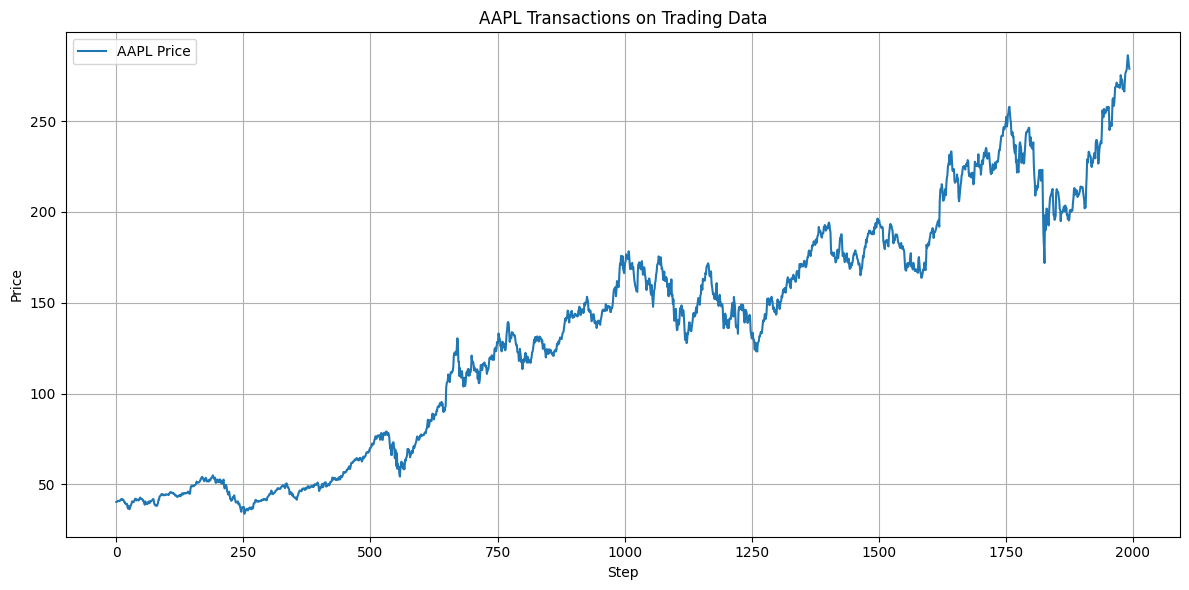

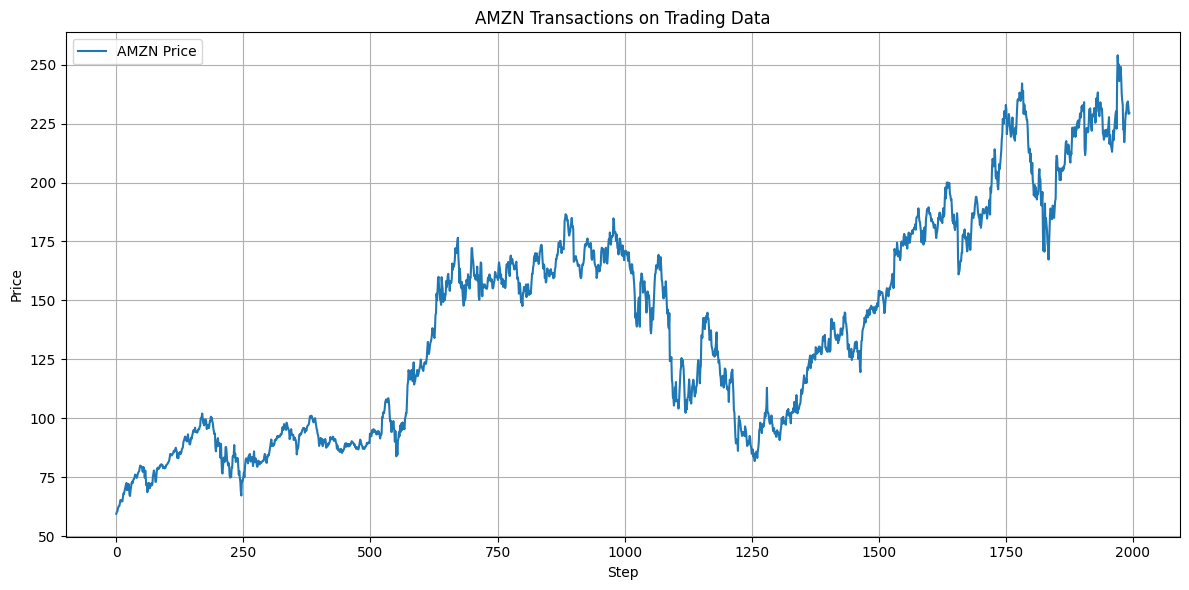

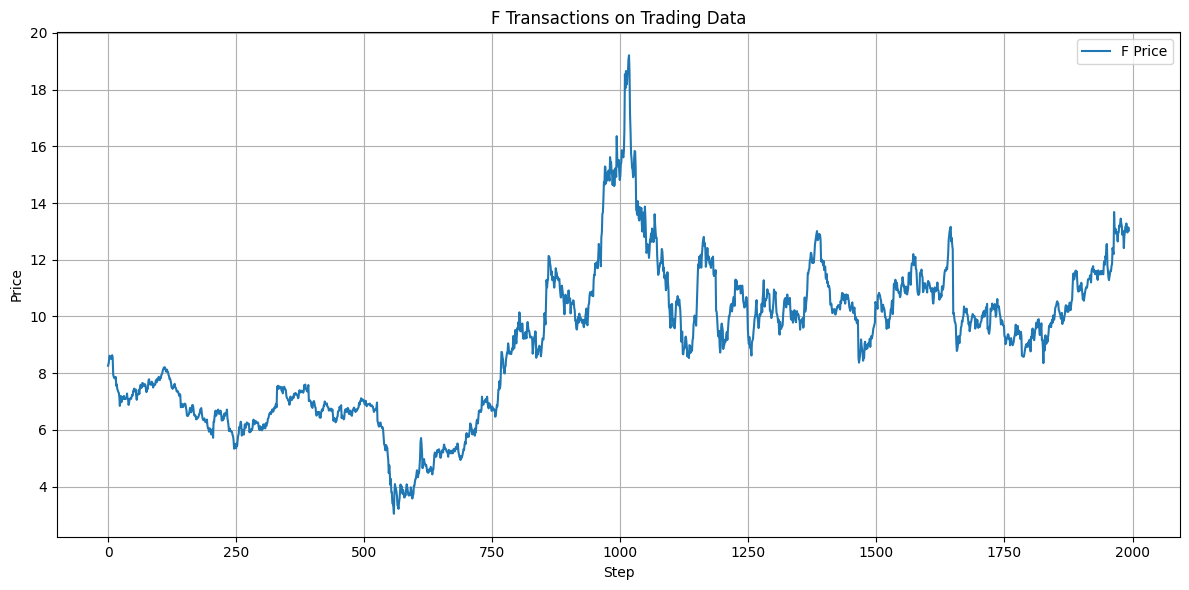

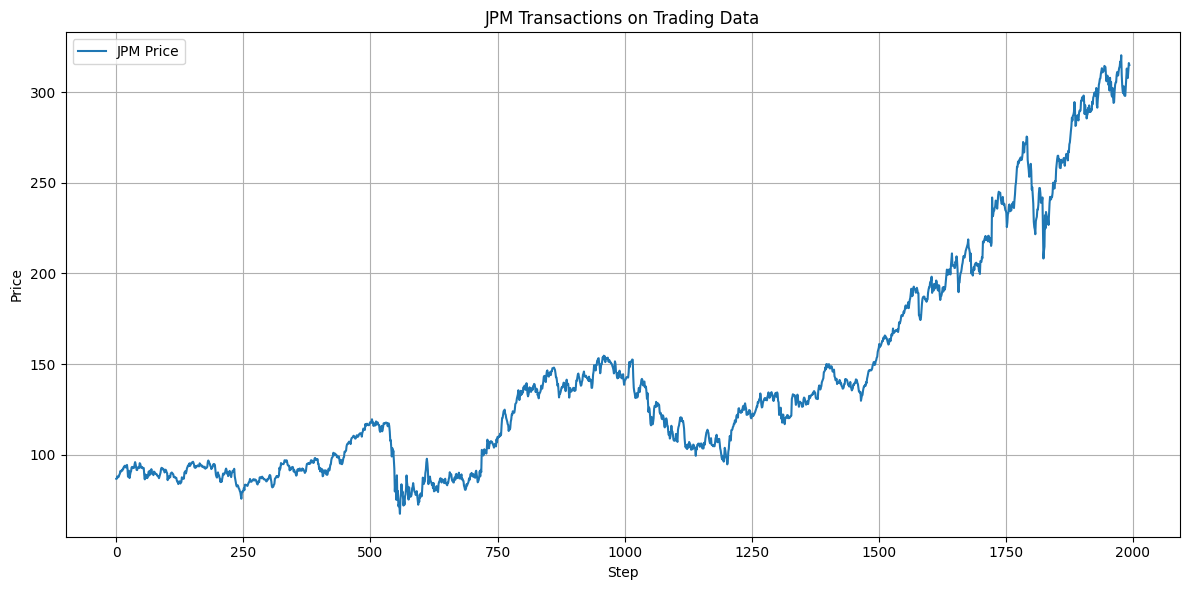

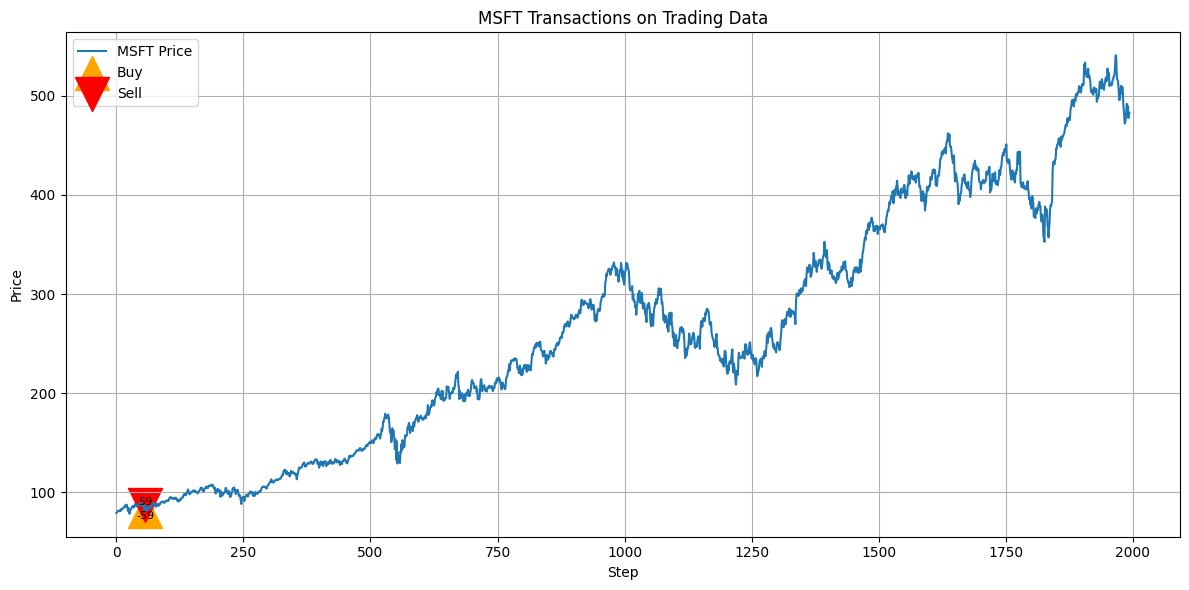

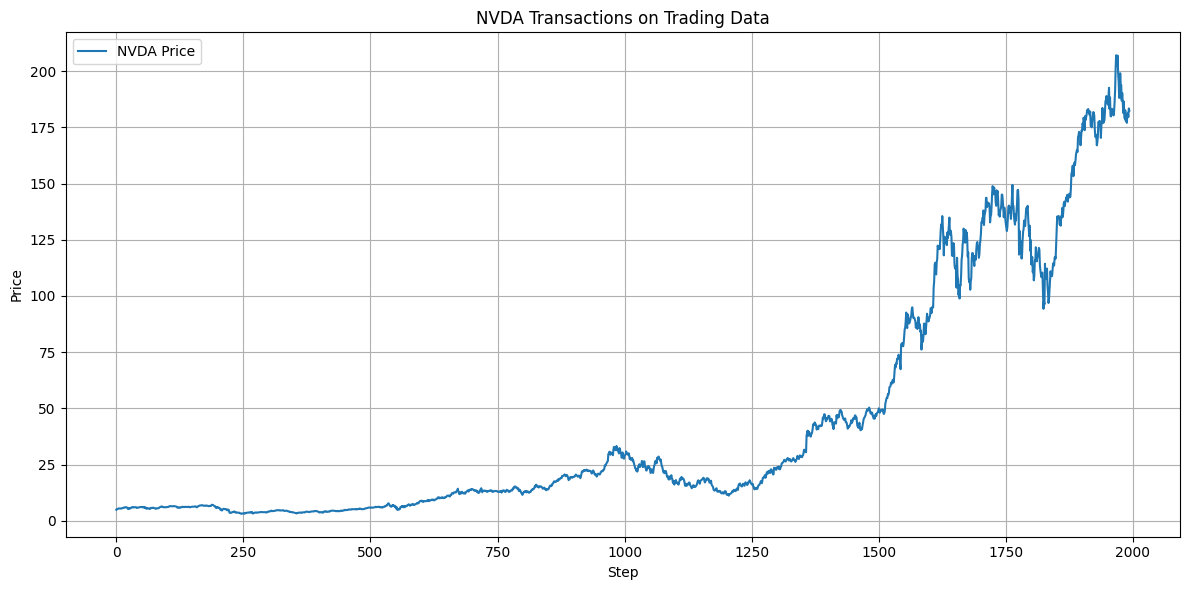

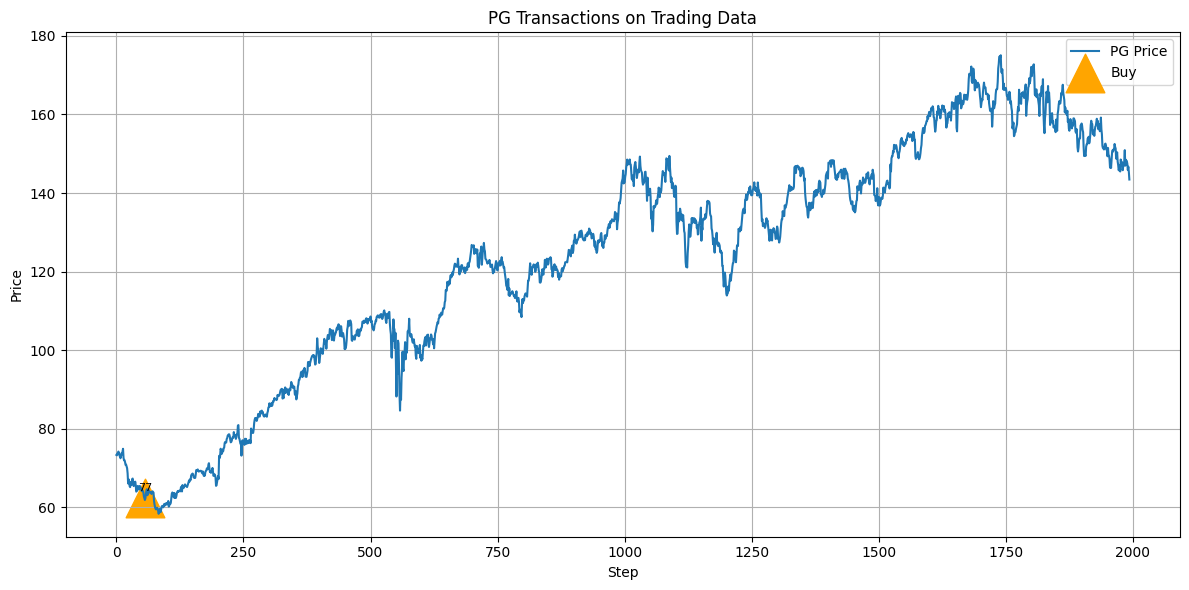

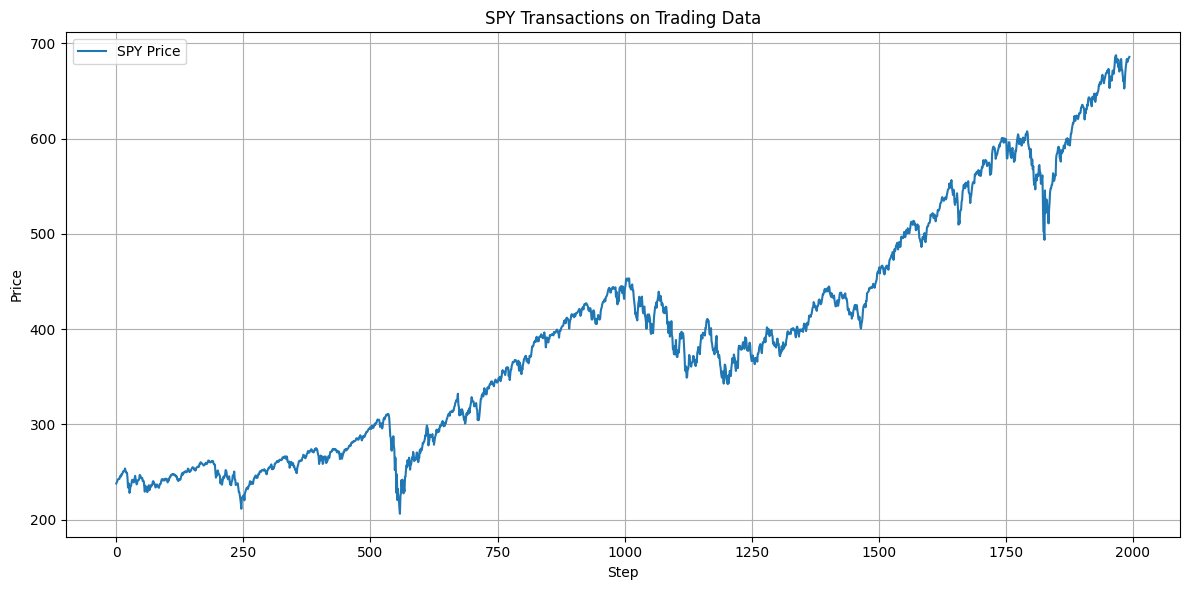

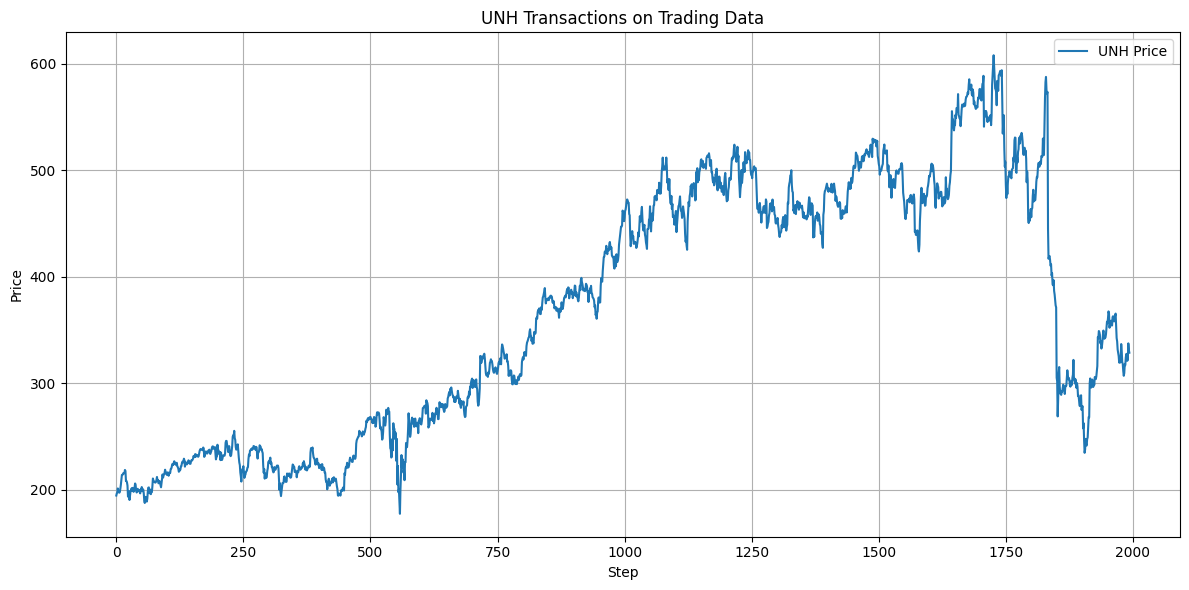

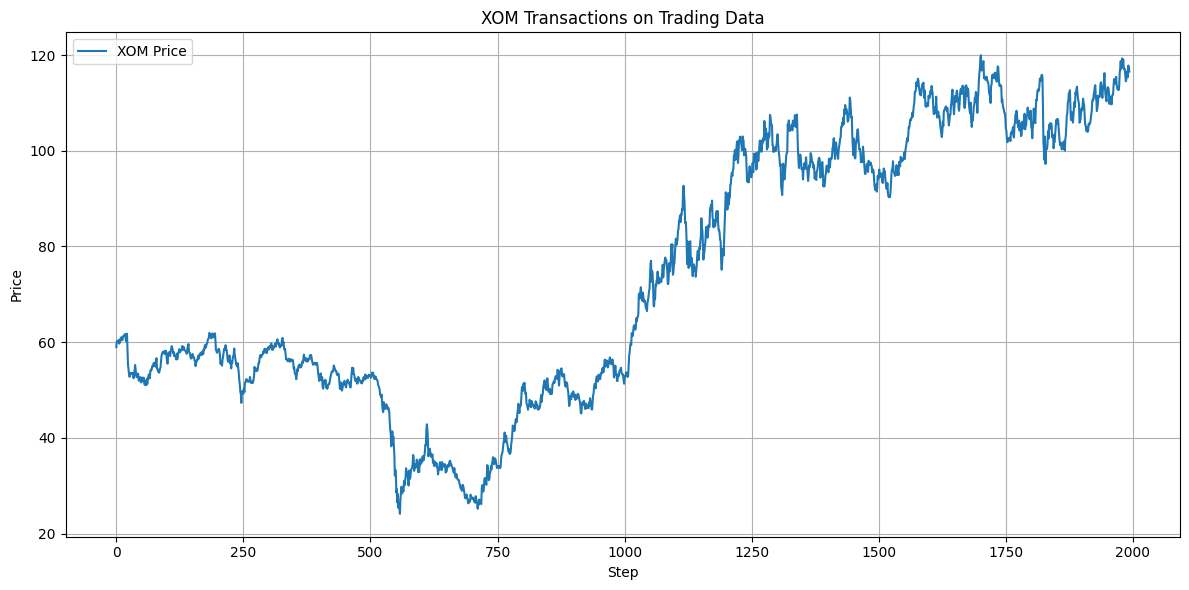

In [29]:
%matplotlib inline
tickers = trade_df['tic'].unique()

for tic in tickers:
    fig, ax = plot_trades_on_price_from_backtest(res, ticker=tic)